# ST 554 Analysis of BigData - HW9: Supervised Learning with Spark MLlib

* Name: Yujin Kim
* Course: ST 554 (601) Spring 2026 Analysis of Big Data
* Assignment: Homework #9

---

For this homework, I use the Adult Income dataset from the UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/2/adult). The goal is to predict whether a person's income is greater than $50K per year. This is a binary classification problem. 

I will use Spark MLlib to:
- clean and prepare the data,
- split the data into training and test sets,
- build three different supervised learning models,
- use pipeline and cross validation for model selection,
- and compare the final model performance on the test set.


In [1]:
import pandas as pd
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/14 20:39:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/04/14 20:39:12 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.


In [2]:
#there are no column name in csv file >> column name reference in adult.name
columns = ["age", "workclass", "fnlwgt", "education", "education_num", 
           "marital_status", "occupation", "relationship", "race", "sex",
           "capital_gain", "capital_loss", "hours_per_week", "native_country",
           "income"]

## 1. Dataset
I use the Adult Income dataset. The response variable is income, which indicates whether a person's annual income is more than $50K.

The dataset includes both numeric and categorical predictors, such as :
- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, ...
- fnlwgt: continuous.
- education: Bachelors, Some-college, 11th, HS-grad, ...
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, ...
- occupation: Tech-support, Craft-repair, Other-service, ...
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous.
- capital-loss: continuous.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, ...

In [3]:
#Read adult.data >> it will concatenate with adult.test

adult_data = spark.read.csv(
    "adult.data",
    header = False,
    inferSchema = False,
    sep = ",",
    ignoreLeadingWhiteSpace = True,
    ignoreTrailingWhiteSpace = True)

adult_data = adult_data.toDF(*columns)

adult_data.show(5)

+---+----------------+------+---------+-------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|       workclass|fnlwgt|education|education_num|    marital_status|       occupation| relationship| race|   sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+----------------+------+---------+-------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
| 39|       State-gov| 77516|Bachelors|           13|     Never-married|     Adm-clerical|Not-in-family|White|  Male|        2174|           0|            40| United-States| <=50K|
| 50|Self-emp-not-inc| 83311|Bachelors|           13|Married-civ-spouse|  Exec-managerial|      Husband|White|  Male|           0|           0|            13| United-States| <=50K|
| 38|         Private|215646|  HS-grad|            9|          Divorced|Handlers-cleaners|Not-i

In [4]:
#Read adult.test >> need processing because adult.test include description and dots.
adult_test = spark.read.csv(
    "adult.test",
    header = False,
    inferSchema = False,
    sep = ",",
    ignoreLeadingWhiteSpace = True,
    ignoreTrailingWhiteSpace = True,
    comment = "|")

adult_test = adult_test.toDF(*columns)

adult_test.show(5)

+---+---------+------+------------+-------------+------------------+-----------------+------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|   education|education_num|    marital_status|       occupation|relationship| race|   sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+------------+-------------+------------------+-----------------+------------+-----+------+------------+------------+--------------+--------------+------+
| 25|  Private|226802|        11th|            7|     Never-married|Machine-op-inspct|   Own-child|Black|  Male|           0|           0|            40| United-States|<=50K.|
| 38|  Private| 89814|     HS-grad|            9|Married-civ-spouse|  Farming-fishing|     Husband|White|  Male|           0|           0|            50| United-States|<=50K.|
| 28|Local-gov|336951|  Assoc-acdm|           12|Married-civ-spouse|  Protective-serv|     Husband|White|  Male|        

## Data Cleaning
Before modeling, I need to clean the dataset.

The Adult dataset requires a few preprocessing steps:
* The income label is `adult.test` end with a period, so I remove it.
* Some categorical values are recorded as `"?"`, which I treat as missing values.
* I combine the two files and then split the data using Spark, since the assignment specifically asks for a Spark MLlib training/test split.
* I create a bianry label column for classification.

In [5]:
#remove dot in adult.test label
from pyspark.sql import functions as F

adult_test = adult_test.withColumn("income", F.regexp_replace(F.col("income"), r"\.", ""))

In [6]:
#merge adult.data and adult.test
df = adult_data.unionByName(adult_test)

In [7]:
#allocate categorical columns
categorical_cols = ["workclass", "education", "marital_status", "occupation",
                    "relationship", "race", "sex", "native_country"]

In [8]:
#? >>> missing
for c in categorical_cols:
    df = df.withColumn(c, F.when(F.trim(F.col(c)) == "?", None).otherwise(F.col(c)))
    
print(df.columns)

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [9]:
#remove missing
df = df.dropna()

In [10]:
#create label: >50K is 1, <=50K is 0
df = df.withColumn("label", F.when(F.col("income") == ">50K", 1).otherwise(0))

In [11]:
#Check data
df.printSchema()
df.show(5)
print("Number of rows after cleaning:", df.count())

root
 |-- age: string (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: string (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: string (nullable = true)
 |-- capital_loss: string (nullable = true)
 |-- hours_per_week: string (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)
 |-- label: integer (nullable = false)

+---+----------------+------+---------+-------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+-----+
|age|       workclass|fnlwgt|education|education_num|    marital_status|       occupation| relationship| race|   sex|capital_gain|capital_loss|hour

In [12]:
#check label distribution
df.groupBy("income", "label").count().show()

+------+-----+-----+
|income|label|count|
+------+-----+-----+
|  >50K|    1|11208|
| <=50K|    0|34014|
+------+-----+-----+



At this stage, the dataset has been cleaned and the target variable has been converted into a binary label. Unknown categorical values were treated as missing and removed, and the two source files were combined into a single dataset.

This cleaned dataset is now ready to be split into training and test sets for model development.

In [13]:
#define numeric columns
numeric_cols = [
    "age", "fnlwgt", "education_num",
    "capital_gain", "capital_loss", "hours_per_week"]

for c in numeric_cols:
    df = df.withColumn(c, F.col(c).cast("int"))

print(df.select(numeric_cols).describe().show())
print(df.printSchema())

26/04/14 20:39:19 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-----------------+------------------+------------------+------------------+------------------+
|summary|               age|           fnlwgt|     education_num|      capital_gain|      capital_loss|    hours_per_week|
+-------+------------------+-----------------+------------------+------------------+------------------+------------------+
|  count|             45222|            45222|             45222|             45222|             45222|             45222|
|   mean|38.547941267524656|189734.7343107337|10.118460041572686|1101.4303436380524|   88.595418159303| 40.93801689443191|
| stddev|13.217870219055536|105639.1951342211|2.5528811950758734| 7506.430083745263|404.95609205896415|12.007508230033459|
|    min|                17|            13492|                 1|                 0|                 0|                 1|
|    max|                90|          1490400|                16|             99999|              4356|                99|
+-------+-------

## Simple EDA
After cleaning and preprocessing the dataset, I performed a simple exploratory data analysis to better understand the distribution of key variables.

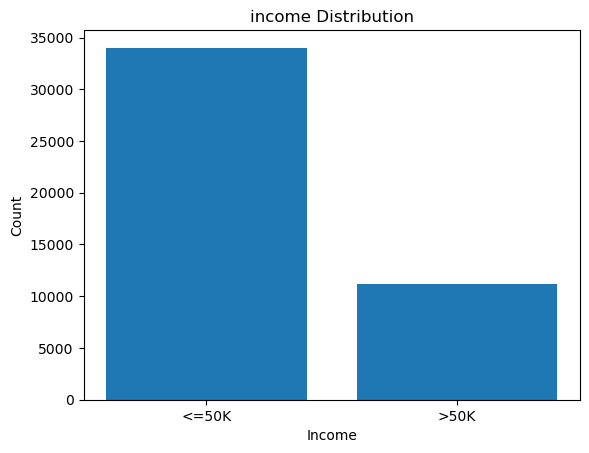

In [14]:
#visualize label distribution
import matplotlib.pyplot as plt

label_counts = df.groupBy("income").count().toPandas()

plt.bar(label_counts["income"], label_counts["count"])
plt.title("income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

The dataset is imbalanced, with a larger number of individuals earning less than or equal to $50K. This justifies the use of evaluation metrics such as AUC and F1 socre.

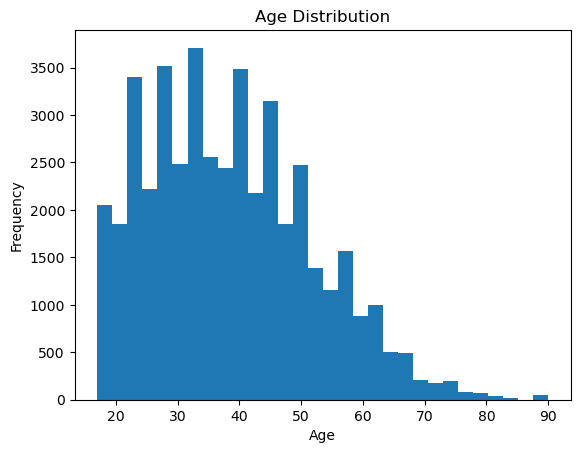

In [15]:
#Age distribution
age_pd = df.select("age").toPandas()

plt.hist(age_pd["age"], bins = 30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows that most individuals fall within the working-age population, with fewer observations at extreme age values.

## 2. Train-Test Split
The assingment requires splitting the data into trianing and test sets using Spark MLlib. I use an 80/20 split, where 80% of the data is used for training and model selection, and 20% is reserved for final testing.

In [16]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed = 42)

print("Training set size:", train_df.count())
print("test set size:", test_df.count())

Training set size: 36280
test set size: 8942


## 3. Evaluation Metric

I use three evaluation metrics: **AUC**, **accuracy**, and **F1 score**.

**AUC**(Area Under the ROC Curve) is used as the primary metric during model selection because it measures the model's ability to distinguish between classes across all thresholds.

**Accuracy** is included for interpretability, as it represents the proportion of correct predictions.

**F1 score** is also reported because it balances precision and recall, which is important when dealing with class imbalance.

In [17]:
#evaluator: AUC
from pyspark.ml.evaluation import BinaryClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol = "rawPrediction",
    metricName = "areaUnderROC")

#evaluator: Accuracy
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_evaluator = MulticlassClassificationEvaluator(
    labelCol = "label",
    predictionCol = "prediction",
    metricName = "accuracy")

#evaluator: F1 score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol = "label",
    predictionCol = "prediction",
    metricName = "f1")

## 4. Models

I comapre three different model classes:

**1. Logistic Regression**
Logostic regression is a linear classification model that estimates the probability that an observation belongs to the positive class. It is simple, interpretable, and often provides a strong baseline.

**2. Random Forest**
Random forest is an ensemble method that combiens many decision trees. Each tree is trained on a slightly different sample of the data, and the final prediction is based on the combined results of the trees. 

**3. Gradient-Boosted Trees**
Gradient-boosted trees build decision trees sequentially. Each new tree is trained to correct errors made by previous trees, which often leads to strong predictive performance.

### (1) Feature Engineering and Preprocessing
Because the dataset contains both numeric and categorical variables, preprocessing is required before model fitting.

The preprocessing steps include:
* indexing categorical variables,
* one-hot encoding categorical variables,
* creating transformed numeric features,
* assembling all predictors into a feature vector,
* and scaling features for logistic regression.

This preprocessing will be included inside Spark ML pipelines.

In [18]:
#create string indexer output name
indexed_cols = [c + "_idx" for c in categorical_cols]
encoded_cols = [c + "_ohe" for c in categorical_cols]

In [19]:
#generate string indexer
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, SQLTransformer

indexers = [StringIndexer(inputCol = c, outputCol = c + "_idx", handleInvalid = "keep") for c in categorical_cols]

In [20]:
#create one hot encoder 
encoder = OneHotEncoder(
    inputCols = indexed_cols,
    outputCols = encoded_cols,
    handleInvalid = "keep")

In [21]:
#Add SQLTransformer >>> increase number of transformation
sql_transformer = SQLTransformer(statement = """ SELECT *, 
    LOG(1 + capital_gain) AS log_capital_gain,
    LOG(1 + capital_loss) AS log_capital_loss FROM __THIS__ """)

In [22]:
#create feature list
feature_cols = ["age", "fnlwgt", "education_num", 
                "hours_per_week", "capital_gain", "capital_loss", 
                "log_capital_gain", "log_capital_loss"] + encoded_cols

In [23]:
#generate Vector Assembler
assembler = VectorAssembler(
    inputCols = feature_cols,
    outputCol = "features_raw",
    handleInvalid = "keep")

In [24]:
#create StandardScaler
scaler = StandardScaler(
    inputCol = "features_raw",
    outputCol = "features_scaled",
    withMean = False,
    withStd = True)

## 5. Model Training Strategy
I use cross validation to tune each model and select the best hyperparameter setting. Since this is a binary classification problem, I use **AUC** as the primary metric for cross validation and model selection.

After selecting the best version of each model, I evaluate the final test-set performance using three metrics:
* AUC
* Accuracy
* F1 score

This provides a more complete comparison across the three model classes.

In [25]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

### (1) Logistic Regression Model

In [26]:
#Define Logistic Regression model
lr = LogisticRegression(
    featuresCol = "features_scaled",
    labelCol = "label",
    maxIter = 100)

#Logistic Regression pipeline
lr_pipeline = Pipeline(
    stages = indexers + [encoder, sql_transformer, assembler, scaler, lr])

#Logistic Regression parameter grid
lr_param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build())

#Logistic Regression cross validation
lr_cv = CrossValidator(
    estimator = lr_pipeline,
    estimatorParamMaps = lr_param_grid,
    evaluator = auc_evaluator,
    numFolds = 3,
    seed = 42)

In [27]:
#Logistic Regression Training
lr_cv_model = lr_cv.fit(train_df)
lr_best_model = lr_cv_model.bestModel

In [28]:
#prediction and evaluation Logistic Regression
lr_pred = lr_best_model.transform(test_df)

lr_auc = auc_evaluator.evaluate(lr_pred)
lr_acc = acc_evaluator.evaluate(lr_pred)
lr_f1  = f1_evaluator.evaluate(lr_pred)

print("Logistic Regression Test AUC:", lr_auc)
print("Logistic Regression Test Accuracy:", lr_acc)
print("Logistic Regression Test F1:", lr_f1)

Logistic Regression Test AUC: 0.9066810200998386
Logistic Regression Test Accuracy: 0.8466785953925297
Logistic Regression Test F1: 0.8414303301456345


**Logstic Regression Result:**

Logistic regression achieved strong performance as a baseline model. However, since it assumes a linear relationship between features and the log-odds of the outcome, it may not fully capture complex patterns in the data.

### (2) Random Forest Model

In [29]:
#Define Random Forest
rf = RandomForestClassifier(
    featuresCol = "features_raw",
    labelCol = "label",
    seed = 42)

#Random Forest pipeline
rf_pipeline = Pipeline(
    stages = indexers + [encoder, sql_transformer, assembler, rf])

#Random Forest parameter grid
rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build())

#Random Forest cross validation
rf_cv = CrossValidator(
    estimator = rf_pipeline,
    estimatorParamMaps = rf_param_grid,
    evaluator = auc_evaluator,
    numFolds = 3,
    seed = 42)

In [30]:
rf_cv_model = rf_cv.fit(train_df)
rf_best_model = rf_cv_model.bestModel

26/04/14 20:41:52 WARN DAGScheduler: Broadcasting large task binary with size 1004.4 KiB
26/04/14 20:41:53 WARN DAGScheduler: Broadcasting large task binary with size 1454.4 KiB
26/04/14 20:41:54 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/04/14 20:41:54 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/04/14 20:41:56 WARN DAGScheduler: Broadcasting large task binary with size 1667.9 KiB
26/04/14 20:42:04 WARN DAGScheduler: Broadcasting large task binary with size 1140.2 KiB
26/04/14 20:42:05 WARN DAGScheduler: Broadcasting large task binary with size 1758.9 KiB
26/04/14 20:42:06 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/04/14 20:42:08 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/04/14 20:42:09 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/04/14 20:42:12 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/04/14 20:42:23 WARN DAGScheduler: Br

In [31]:
#prediction and evaluation Random Forest
rf_pred = rf_best_model.transform(test_df)

rf_auc = auc_evaluator.evaluate(rf_pred)
rf_acc = acc_evaluator.evaluate(rf_pred)
rf_f1  = f1_evaluator.evaluate(rf_pred)

print("Random Forest Test AUC:", rf_auc)
print("Random Forest Test Accuracy:", rf_acc)
print("Random Forest Test F1:", rf_f1)

26/04/14 20:43:42 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/04/14 20:43:43 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/04/14 20:43:44 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


Random Forest Test AUC: 0.90208423251891
Random Forest Test Accuracy: 0.837396555580407
Random Forest Test F1: 0.8251812540264238


**Random Forest Result:**

Random forest can capture nonlinear relationships and interactions among predictors. After cross validation, I evaluated the best random forest model on the test set using the same three metrics.

Compared to logistic regression, random forest can model nonlinear relationships and feature interaction, but its performance in this case was slightly lower than the gradient-boosted trees.

### (3) Gradient-Boosted Trees

In [32]:
#Define GBT model
gbt = GBTClassifier(
    featuresCol = "features_raw",
    labelCol = "label",
    seed = 42)

#GBT pipeline
gbt_pipeline = Pipeline(
    stages = indexers + [encoder, sql_transformer, assembler, gbt])

#GBT parameter grid
gbt_param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [20, 50])
    .build())

#GBT cross validation
gbt_cv = CrossValidator(
    estimator = gbt_pipeline,
    estimatorParamMaps = gbt_param_grid,
    evaluator = auc_evaluator,
    numFolds = 3,
    seed = 42)

In [ ]:
#GBT Training
gbt_cv_model = gbt_cv.fit(train_df)
gbt_best_model = gbt_cv_model.bestModel

26/04/14 20:46:06 WARN BlockManager: Asked to remove block broadcast_10618, which does not exist


In [ ]:
#prediction and evaluation GBT
gbt_pred = gbt_best_model.transform(test_df)

gbt_pred = gbt_best_model.transform(test_df)

gbt_auc = auc_evaluator.evaluate(gbt_pred)
gbt_acc = acc_evaluator.evaluate(gbt_pred)
gbt_f1  = f1_evaluator.evaluate(gbt_pred)

print("Gradient-Boosted Trees Test AUC:", gbt_auc)
print("Gradient-Boosted Trees Accuracy:", gbt_acc)
print("Gradient-Boosted Trees Test F1:", gbt_f1)

**Gradient-Boosted Trees Result:**

Grident-boosted trees are often strong predictive models because they iteratively correct previous errors. After tuning with cross validation, I evaluated the best GBT model on the test set.

The superior performance of gradient-boosted trees suggests that capturing sequential error corrections improves predictive performance for this dataset.

In [ ]:
#result comparison

results = [
    ("Logistic Regression", lr_auc, lr_acc, lr_f1),
    ("Random Forest", rf_auc, rf_acc, rf_f1),
    ("Gradient-Boosted Trees", gbt_auc, gbt_acc, gbt_f1)]

results_df = spark.createDataFrame(results, ["model", "test_auc", "test_accuracy", "test_f1"])

results_df.show(truncate = False)

In [ ]:
#sorted by AUC >> best AUC considered best model
results_df.orderBy(F.col("test_auc").desc()).show(truncate = False)

In [ ]:
best_result = max(results, key=lambda x: x[1])

print("Best overall model:", best_result[0])
print("Best Test AUC:", best_result[1])
print("Best Test Accuracy:", best_result[2])
print("Best Test F1:", best_result[3])

I compared three different supervised learning model classes using Spark MLlib:
* Logistic Regression
* Random Forest
* Gradient-Boosted Trees

Cross validation was performed using AUC as the primary model selection metric. After selecting the best version of each model, I evaluated them on the test set using AUC, accuracy, and F1 score.

The best overall model was **Gradient-Boosted Trees**.

Its final testset performance was:
* AUC: 0.9106
* Accuracy: 0.8507
* F1 Score: 0.8451

Based on these results, Gradient-Boosted Trees provided the strongest overall performance on this dataset. This suggests that a boosted tree-based model was better able to capture nonlinear relationships and interactions among the predictors than the other model classes.

This homework showed how Spark MLlib pipelines can be used to combine preprocessing, feature engineering, model fitting, and cross validation in a structured supervised learning workflow.